# CE6021 Section 2 Assignment . - Scale Invariant "blob" keypoint detector. 

In this assignment you will code a scale invariant keypoint detector that can detect circular or blob like regions in an image. The goal of the assignment is to build a detector so that the dark circular regions in the centres of the sunflowers at different scales in the image can be found & marked.
![](https://github.com/tonyscan6003/etivities/blob/main/blob_flowers.JPG?raw=true)


As we have seen in the notes there are several possible ways to buid such a keypoint detector. For this assignment you will construct a Laplacian (of gaussian) scale space for the test image, and then seach this scale space for maxima that correspond to blobs in the image at different scales.

We will firstly load the required python packages and import the test image of sunflowers and display it. 

In [1]:
from pathlib import Path

import cv2
import numpy as np
from matplotlib import pyplot as plt
from scipy import signal
from tqdm import tqdm

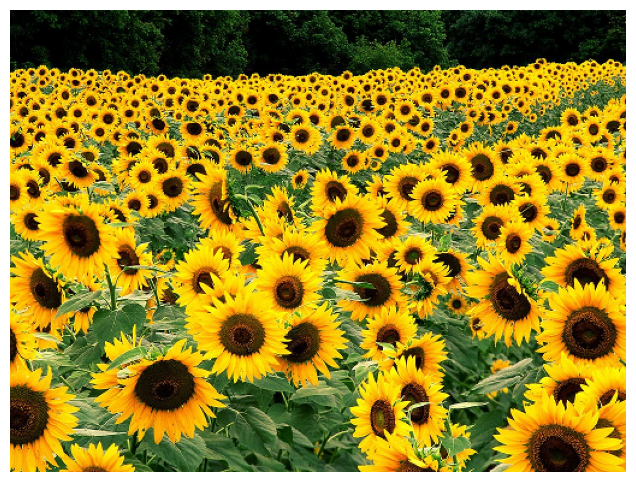

In [2]:
# Local copy of the image supplied in the assignment:
# https://live.staticflickr.com/3142/2858995030_e9afccdc11_b.jpg
assignment_dir = Path.cwd()
if not (assignment_dir / "resources/sunflowers.jpg").exists():
    assignment_dir = assignment_dir / "Assignment2"


def read_image():
    image = cv2.imread(str(assignment_dir / "resources/sunflowers.jpg"))
    if image is None:
        raise FileNotFoundError("Cannot load resources/sunflowers.jpg")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image.shape[:2]
    image = cv2.resize(image, (width // 2, height // 2), interpolation=cv2.INTER_CUBIC)
    # The display image is already RGB, so use the matching grayscale conversion.
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return image, gray


image_scale, gray = read_image()
plt.figure(figsize=(8, 6))
plt.imshow(image_scale)
plt.axis("off")
plt.show()

# Laplacian Scale Space:

Our goal in this section is to generate a laplacian scale space for the test image. We will perform this in three steps.

> **Step 1**: We will code a function that can generate kernel functions i.e. the 2nd order paratial derivatives of the gaussian function  $\frac{\partial^2{G(\mathbf{x},\sigma)}}{\partial{x}^2}$,$\frac{\partial^2{G(\mathbf{x},\sigma)}}{\partial{y}^2}$. 

> **step 2**: We will code a function that convolves the image with gaussian derivative kernels to produce the Laplacian of Gaussians for any value of sigma.

> **Step 3**: We will use the convolution function we have just written in a for loop to create the scale space images and assign them to an array.

**Computation of kernels:**
As shown in the notes 2_2 (part B) (slide 4) the Laplacian scale space (for a given sigma) is formed from convolution of the partial derivatives of the gaussian kernel with the input image.
It is however computationally inefficient to convolve these large 2d kernels with the image. *Therefore the gaussian partial derivative kernels should be instead determined as seperable convoutions*. That is 2 sequential convolutions with 1d kernels. 

Useful Information:
> The gaussian 1d forms including the 1st and 2nd order derivatives can be found [here](http://www.sci.utah.edu/~gerig/CS7960-S2010/handouts/04%20Gaussian%20derivatives.pdf)

> Seperable convolutions: Lecture 1_2 & [here](http://www.songho.ca/dsp/convolution/convolution2d_separable.html)

> [Scipy 2d Convolution command](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve2d.html) (can be used with 1xn arrays as well as m x n):

> Numpy expand dims can be used to turn a list into an array

> Numpy transpose can be used to obtain transpose of an array



**Scale space range**: The code cell below defines a range of sigma values to generate your scale space over.

In [3]:
# Define Scale space
sigma_min = 1
sigma_max = 32
scale_fac = 1.05
# number of filters in scale space
num_scales = int((sigma_max-sigma_min)/scale_fac)
print("The number of scales is ",num_scales)
sigma_vals = np.linspace(sigma_min,sigma_max,num_scales) # Range of sigma values for scale space

The number of scales is  29


**Step 1:** In the code cell below you should complete the function that can output the 1d kernels that can be used to form the 2d Gaussians derivative kernels $\frac{\partial^2{G(\mathbf{x},\sigma)}}{\partial{x}^2}$,$\frac{\partial^2{G(\mathbf{x},\sigma)}}{\partial{y}^2}$ for a given sigma value. Hint: The same two 1d kernels are necessary to generate both 2D gaussian derivative kernels.

Note 
> When generating 1d gaussian kernels it is necessary to ensure there are enough samples in the window for the gaussian to decay to zero (see lecture 1_2). With larger sigma values bigger kernels are needed. The code snippet below gives the range of samples needed for generating gaussian kernels of different sizes.
```
    k_size = int(6*sigma+1)
    rng = (k_size-1)//2
    x = np.arange(-rng,rng+1)
```



In [4]:
def gauss_kernels(sigma):
    """Return row kernels for the Gaussian G and its second derivative G''."""
    if sigma <= 0:
        raise ValueError("sigma must be positive")
    # Sample approximately three standard deviations on either side.
    radius = int(np.ceil(3 * sigma))
    x = np.arange(-radius, radius + 1, dtype=float)
    gaussian = np.exp(-x**2 / (2 * sigma**2)) / (np.sqrt(2 * np.pi) * sigma)
    second_derivative = ((x**2 - sigma**2) / sigma**4) * gaussian
    return gaussian[None, :], second_derivative[None, :]

Before moving to the next step, You can test if you can correctly generate the required 2D kernels from the 1D kernels by obtaining the outer product of the 1d kernels and plotting the result.

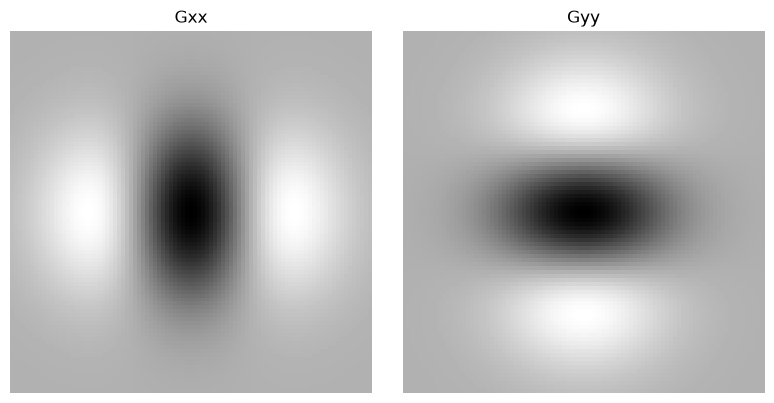

In [5]:
K1, K2 = gauss_kernels(15)
K_2d_x = K1.T @ K2  # Smooth vertically, differentiate horizontally.
K_2d_y = K2.T @ K1

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, kernel, title in zip(axes, (K_2d_x, K_2d_y), ("Gxx", "Gyy")):
    ax.imshow(kernel, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Step 2:** In the code cell below you should complete the function that can output the normalised lapacian of a greyscale image for a given sigma value. You can re-use the function to generate the 1d kernels and then convolve the input image using seperable convolution as mentioned above.

In [6]:
def laplacian(sigma, image):
    """Compute the scale normalised LoG using separable 1D convolutions."""
    K1, K2 = gauss_kernels(sigma)
    image = np.asarray(image, dtype=float)
    # Symmetric padding avoids introducing a black border around the image.
    Lxx = signal.convolve2d(image, K2, mode="same", boundary="symm")
    Lxx = signal.convolve2d(Lxx, K1.T, mode="same", boundary="symm")
    Lyy = signal.convolve2d(image, K1, mode="same", boundary="symm")
    Lyy = signal.convolve2d(Lyy, K2.T, mode="same", boundary="symm")
    # Normalisation makes response strengths comparable across scales.
    return sigma**2 * (Lxx + Lyy)

**Step 3:** Using the function that you have written, we will now iterate through the given sigma values and stack (using dstack) each scale space image to the array `laplace_scale_space`. This output array should be of dimension $n\times m \times k$ where $n$ and $m$ are the dimensions of the image and $k$ is the number of scales (`num_scales`).
We use greyscale image `gray` with your function along with each sigma value (not the original color image).

np.dstack: https://docs.scipy.org/doc/numpy/reference/generated/numpy.dstack.html





In [7]:
responses = []
for sigma in tqdm(sigma_vals, desc="Building scale space"):
    responses.append(laplacian(sigma, gray))
laplace_scale_space = np.dstack(responses)


Building scale space:   0%|          | 0/29 [00:00<?, ?it/s]


Building scale space:  14%|█▍        | 4/29 [00:00<00:00, 28.47it/s]


Building scale space:  24%|██▍       | 7/29 [00:00<00:01, 16.42it/s]


Building scale space:  31%|███       | 9/29 [00:00<00:01, 13.00it/s]


Building scale space:  38%|███▊      | 11/29 [00:00<00:01, 10.62it/s]

...


Building scale space:  90%|████████▉ | 26/29 [00:04<00:00,  3.21it/s]


Building scale space:  93%|█████████▎| 27/29 [00:04<00:00,  3.10it/s]


Building scale space:  97%|█████████▋| 28/29 [00:05<00:00,  3.01it/s]


Building scale space: 100%|██████████| 29/29 [00:05<00:00,  2.92it/s]


Building scale space: 100%|██████████| 29/29 [00:05<00:00,  5.15it/s]

In [8]:
print(np.shape(laplace_scale_space))

(384, 512, 29)


**View Lapacian Scale Space** If you have correctly generated the lapacian scale space, you can use the function in the cell below to visualise the scale space. The function will plot the laplacian and the square of the laplacian. (Note that your laplacian scale space will contain both positive and negative values, but the plot function will automatically offset and scale the values for dispay)

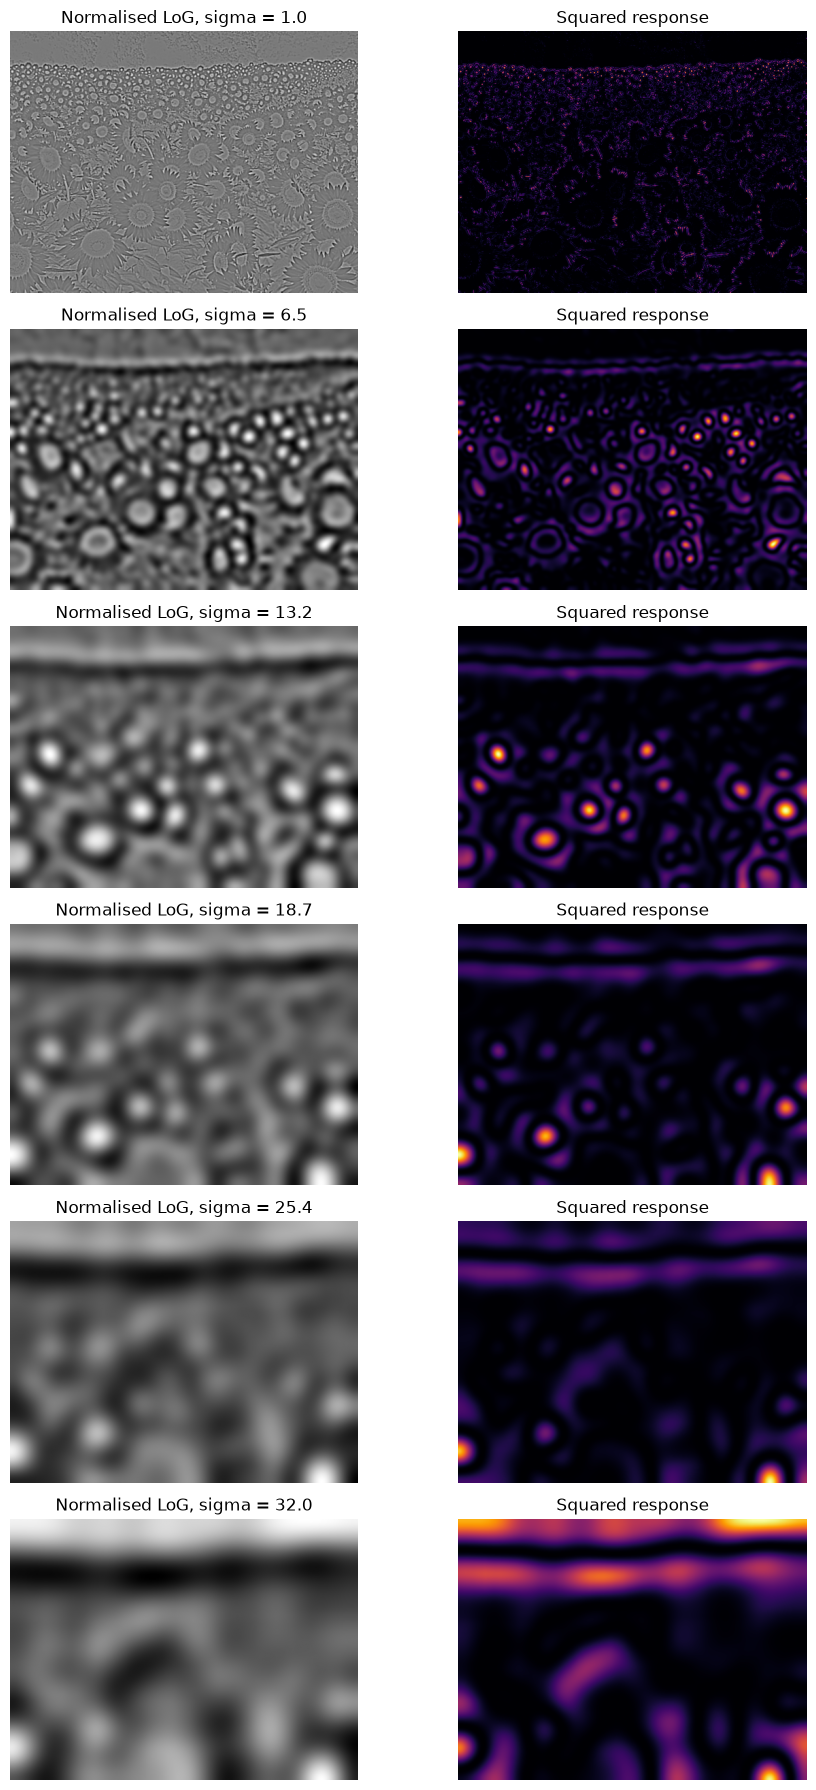

In [9]:
# Show representative scales without creating an oversized figure.
selected_scales = np.linspace(0, num_scales - 1, 6, dtype=int)
fig, axes = plt.subplots(len(selected_scales), 2, figsize=(10, 18))
for row, k in enumerate(selected_scales):
    response = laplace_scale_space[:, :, k]
    axes[row, 0].imshow(response, cmap="gray")
    axes[row, 0].set_title(f"Normalised LoG, sigma = {sigma_vals[k]:.1f}")
    axes[row, 1].imshow(response**2, cmap="inferno")
    axes[row, 1].set_title("Squared response")
    for ax in axes[row]:
        ax.axis("off")
plt.tight_layout()
plt.show()

# Maxima Detection.
If you have completed the notebook successfuly to this point, you should be able to see the maxima in the Normalised Laplacian image that you generated correspond to the stuctures in the original image. It should be evident that the reponse is maximised at particular scales (sigma values) and at particular locations in the image. (Images should be similar to slide 3 of lecture 2_2 part B)

The next step is to find the exact location of the local maxima in x,y space and scale. This may be achieved by iterating though all of the scale space images and determining if each point in scale space is a local maximum by comparing it's magnitude with each of it's 26 nearest neighbours (as shown in slide 6 of the lecture slides 2_2 part B). You should be able to convince yourself with a simple 1d example that this algorithm can find local maxima over all scales and positions.

In the code cell below complete the function `lap_max_det` . This function sets the conditions for detection of a maxima.  A threshold value `thresh` should be included to ensure that we include the strong maxima and avoid too many detections. This function should return a list `max_det` when a maxima is detected (it returns an empty list otherwise). The magnitude of the detected maximum in Laplacian scale space, the x,y position and the scale sigma are stored in the list.  

The lap_max_det function is then used in the function `find_maxima` which contains a for loop (given) that iterates over all points in scale space and applies your condition to detect maxima.

Notes:

> The first and last images in the scale space are treated as auxillary images (i.e. These scale spaced are only used to assist in the determination of maxima of the 2nd and 2nd last layers.) 

> The numpy [ravel](https://numpy.org/doc/stable/reference/generated/numpy.ravel.html) command may be useful



 



In [10]:
thresh = 40  # Start here so higher thresholds can be compared without rerunning the search.


def lap_max_det(x, y, k, thresh, scale_space, sigmas):
    """Return [magnitude, row, column, sigma] for a dark blob maximum."""
    response = scale_space[x, y, k]
    # With this LoG sign convention, dark centres have a positive response.
    if response <= thresh:
        return []
    window = np.abs(scale_space[x - 1:x + 2, y - 1:y + 2, k - 1:k + 2]).ravel()
    # The centre is index 13 in the 3 x 3 x 3 neighbourhood.
    neighbours = np.delete(window, 13)
    if response > neighbours.max():
        return [response, x, y, sigmas[k]]
    return []


def find_maxima(scale_space, sigmas, thresh):
    """Search interior positions and scales, returning an N x 4 array."""
    height, width, scales = scale_space.shape
    detections = []
    for k in tqdm(range(1, scales - 1), desc="Finding maxima"):
        for x in range(1, height - 1):
            for y in range(1, width - 1):
                detection = lap_max_det(x, y, k, thresh, scale_space, sigmas)
                if detection:
                    detections.append(detection)
    return np.asarray(detections, dtype=float).reshape(-1, 4)


max_coords = find_maxima(laplace_scale_space, sigma_vals, thresh)
print(f"Detected {len(max_coords)} dark blob candidates at threshold {thresh}.")
for threshold in (40, 50, 60):
    print(f"Threshold {threshold}: {np.count_nonzero(max_coords[:, 0] > threshold)} detections")

# Use the cleanest of the three visual comparisons for the final overlay.
selected_threshold = 60
selected_coords = max_coords[max_coords[:, 0] > selected_threshold]


Finding maxima:   0%|          | 0/27 [00:00<?, ?it/s]


Finding maxima:   7%|▋         | 2/27 [00:00<00:01, 15.40it/s]


Finding maxima:  15%|█▍        | 4/27 [00:00<00:01, 15.83it/s]


Finding maxima:  22%|██▏       | 6/27 [00:00<00:01, 16.08it/s]


Finding maxima:  30%|██▉       | 8/27 [00:00<00:01, 16.39it/s]

...


Finding maxima:  74%|███████▍  | 20/27 [00:01<00:00, 20.94it/s]


Finding maxima:  85%|████████▌ | 23/27 [00:01<00:00, 20.03it/s]


Finding maxima:  96%|█████████▋| 26/27 [00:01<00:00, 19.67it/s]


Finding maxima: 100%|██████████| 27/27 [00:01<00:00, 18.40it/s]

Detected 520 dark blob candidates at threshold 40.
Threshold 40: 520 detections
Threshold 50: 361 detections
Threshold 60: 288 detections


**Display Maxima** The code below is provided to help you display you found keypoints over the original image. (some minor modification may be necessary depending on how you stored the keypoints from the last cell)

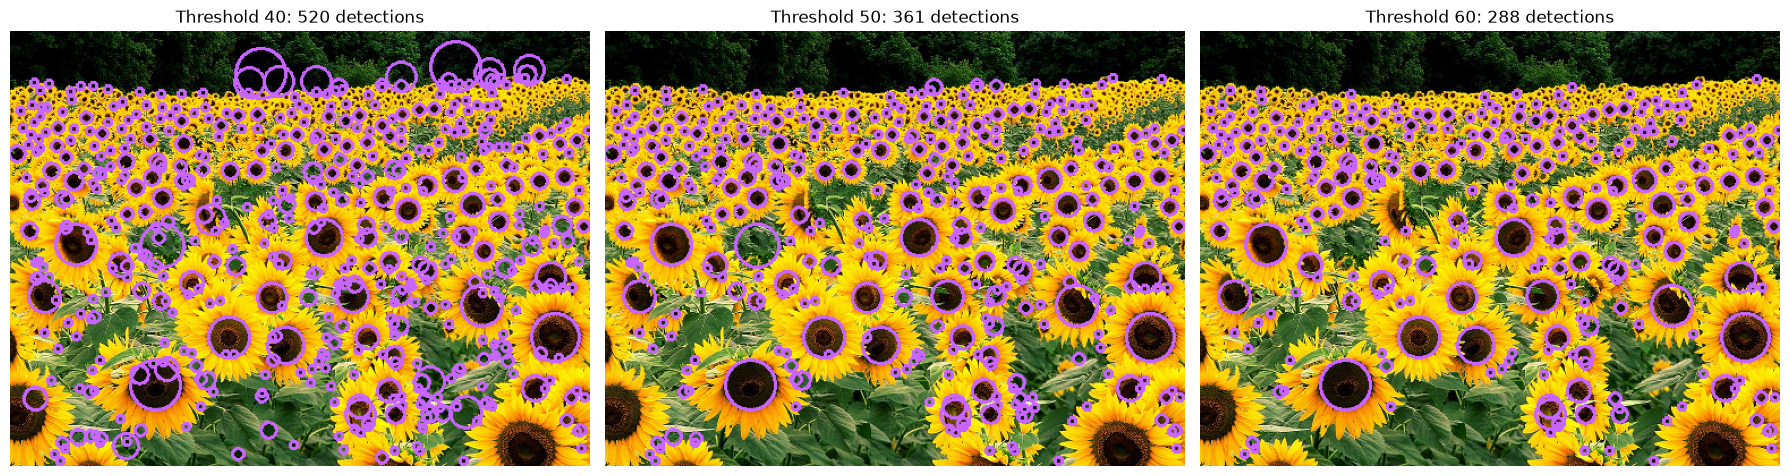

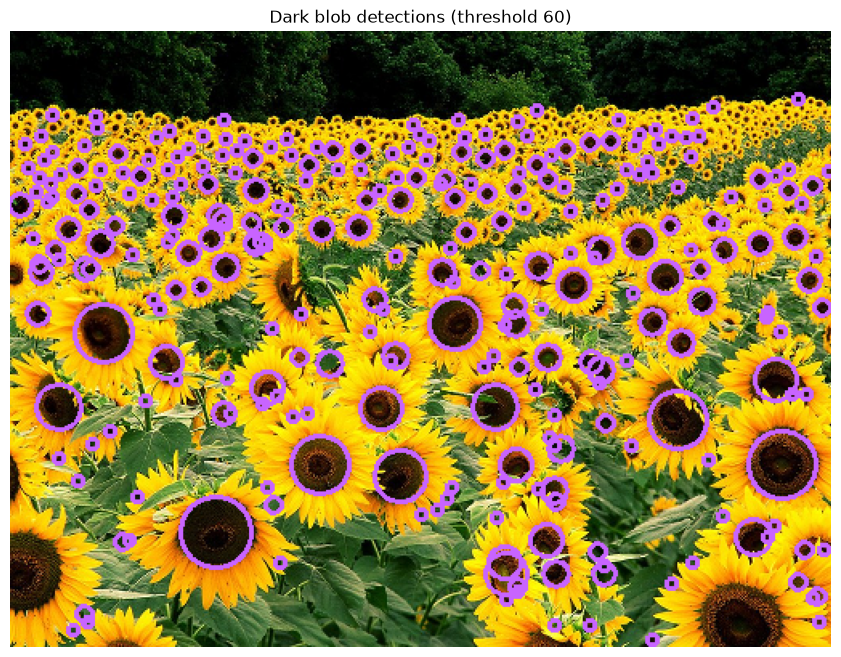

In [11]:
def draw_detections(image, detections):
    """Draw a circle at each blob centre using its detected scale."""
    overlay = image.copy()
    for magnitude, row, column, sigma in sorted(detections, key=lambda item: -item[0]):
        radius = int(np.ceil(np.sqrt(2) * sigma))
        cv2.circle(overlay, (int(column), int(row)), radius, (200, 100, 255), 2)
    return overlay


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, threshold in zip(axes, (40, 50, 60)):
    detections = max_coords[max_coords[:, 0] > threshold]
    ax.imshow(draw_detections(image_scale, detections))
    ax.set_title(f"Threshold {threshold}: {len(detections)} detections")
    ax.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
plt.imshow(draw_detections(image_scale, selected_coords))
plt.title(f"Dark blob detections (threshold {selected_threshold})")
plt.axis("off")
plt.show()

**Comments:** I used a Gaussian and its second derivative as the two 1D kernels. Two sequential convolutions give each directional second derivative; their sum is multiplied by $\sigma^2$ for scale normalisation. At each interior position and scale, I compare the candidate magnitude with the 26 neighbouring magnitudes. I retain positive responses because, with this Laplacian sign convention, the dark sunflower centres give positive peaks. Negative peaks often correspond to bright petals.

The completed run produced a 384 × 512 × 29 scale space. Thresholds 40, 50 and 60 gave 520, 361 and 288 dark blob candidates. The threshold 60 overlay is visibly less cluttered, but some circles still overlap or mark other dark structures.